In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import random
import math
from task_sampler import task_shift, f, get_batch, get_batch_test, get_batch_val
import scipy
import matplotlib
import matplotlib.pyplot as plt


0
173
60
42
157


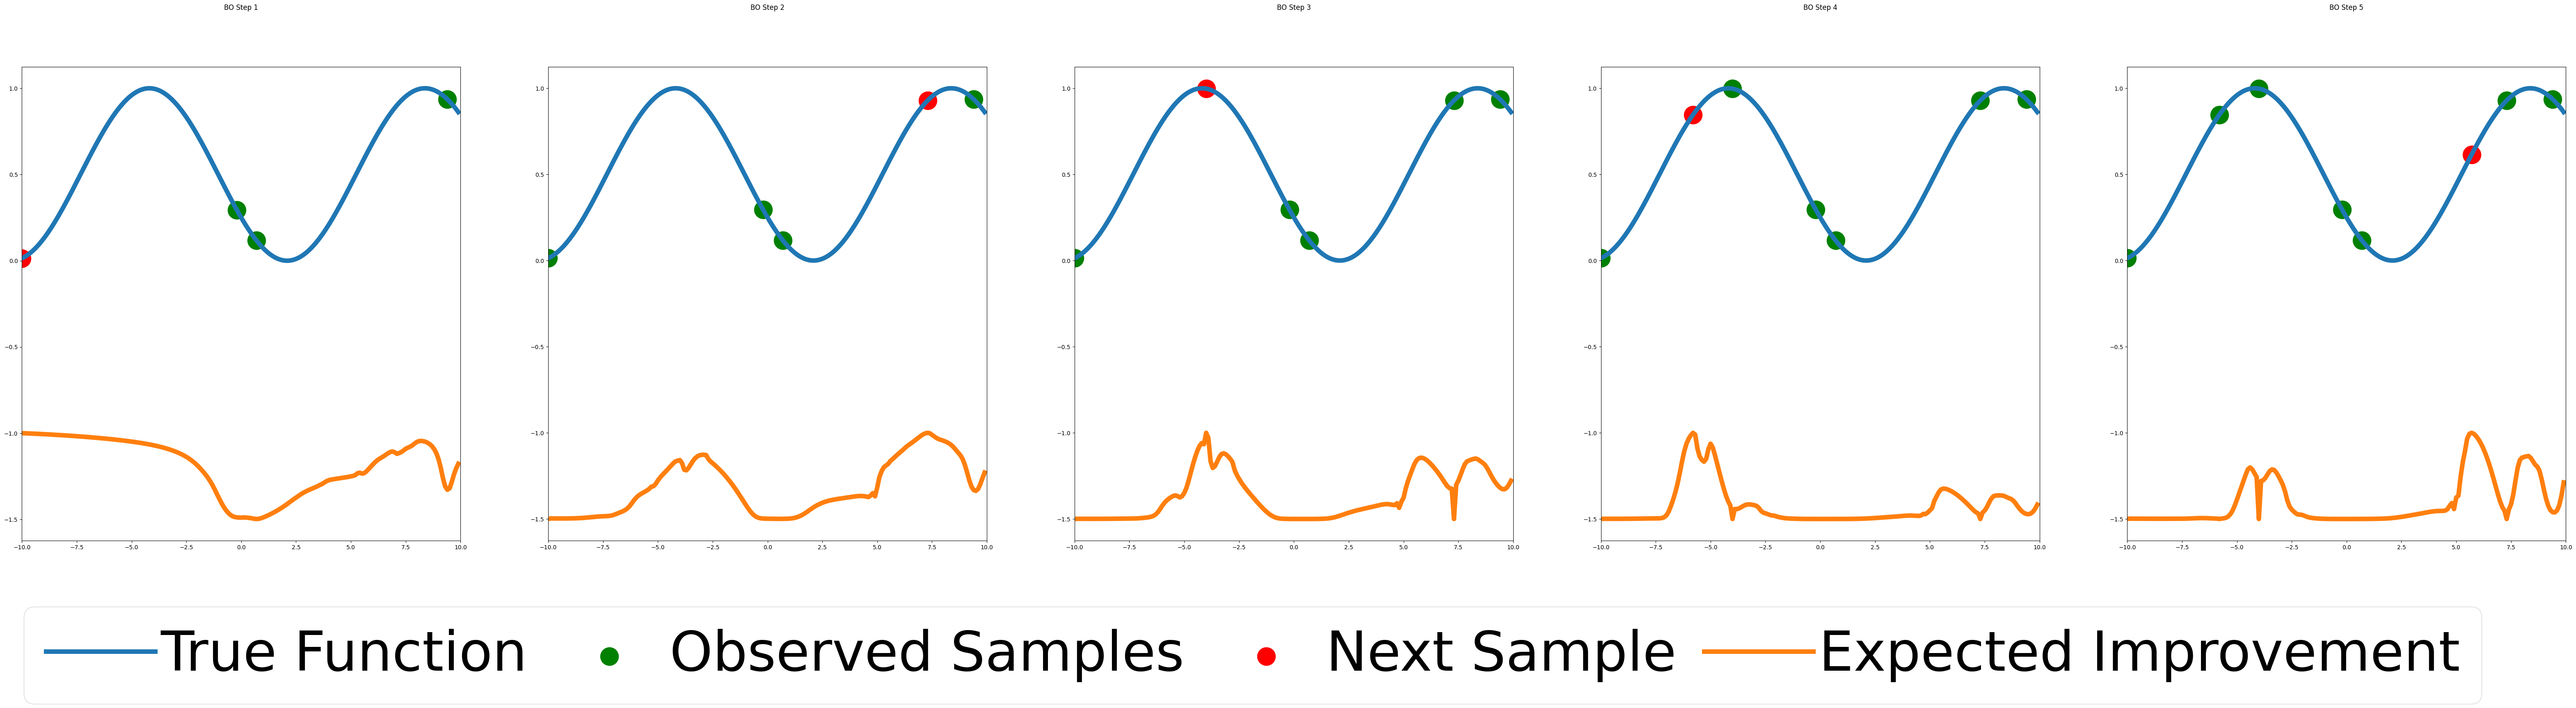

In [3]:
from simple_pfns4bo import PFNs4BO_discrete
import pfns4bo
from pfns4bo.scripts.tune_input_warping import fit_input_warping


np.random.seed(0)
random.seed(0)
torch.manual_seed(0)

iterations = 5
lw = 8
factor=1.2
fontsize = 80


X_spt, y_spt, X_qry, y_qry = get_batch_test(spt_size=3, task = 8   )

optimizer  = PFNs4BO_discrete(torch.load( pfns4bo.hebo_plus_model))


for x,y in zip(X_spt,y_spt):
    optimizer.observe(x, y)


text_array = ["BO Step 1", "BO Step 2", "BO Step 3" , "BO Step 4", "BO Step 5", "BO Step 5"]

fig, axs = plt.subplots(1,iterations, figsize=(80,15))
#fig2, axs2 = plt.subplots(1,iterations, figsize=(80,15))
evaluated_indices = []
for i in range(iterations):                
    incumbent = X_spt[y_spt.argmax()].reshape(-1)
    idx_next, acq_values = optimizer.suggest(candidates=X_qry)
    print(idx_next)
    optimizer.observe(X_qry[idx_next], y_qry[idx_next])
    X_spt = torch.cat((X_spt, X_qry[idx_next].unsqueeze(-1)))
    y_spt = torch.cat((y_spt, y_qry[idx_next].unsqueeze(-1)))
    axs[i].plot(X_qry*10,y_qry, linewidth=lw, label="True Function")
    axs[i].scatter(X_spt[:-1]*10, y_spt[:-1], s= 1000, c= "green", label="Observed Samples")
    axs[i].scatter(X_spt[-1]*10, y_spt[-1], s= 1000, c= "red", label="Next Sample")
    
    ei = 0.5*acq_values/max(acq_values) - 1.5
    axs[i].plot(X_qry*10, ei, linewidth=lw, label="Expected Improvement")
    axs[i].set_xlim(-10,10)
    axs[i].set_title(text_array[i], pad=100)

   
lines_labels = [ax.get_legend_handles_labels() for ax in fig.axes[:1]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
fig.legend(lines, labels,loc="lower center", bbox_to_anchor=(0.5, -0.2), ncol=4, fontsize=fontsize*factor,  handletextpad=0.1, labelspacing = 0.2, columnspacing=0.5)

fig.subplots_adjust(wspace=0.2)

In [4]:
X_spt, y_spt, X_qry, y_qry = get_batch_test(spt_size=3, task = 8   )
X_spt.shape

torch.Size([3, 1])

Reliability scores: tensor([0.0938, 0.1815, 0.1815, 0.1814, 0.1812, 0.1806])
Reliability scores: tensor([0.0938, 0.1815, 0.1815, 0.1814, 0.1812, 0.1806])
159


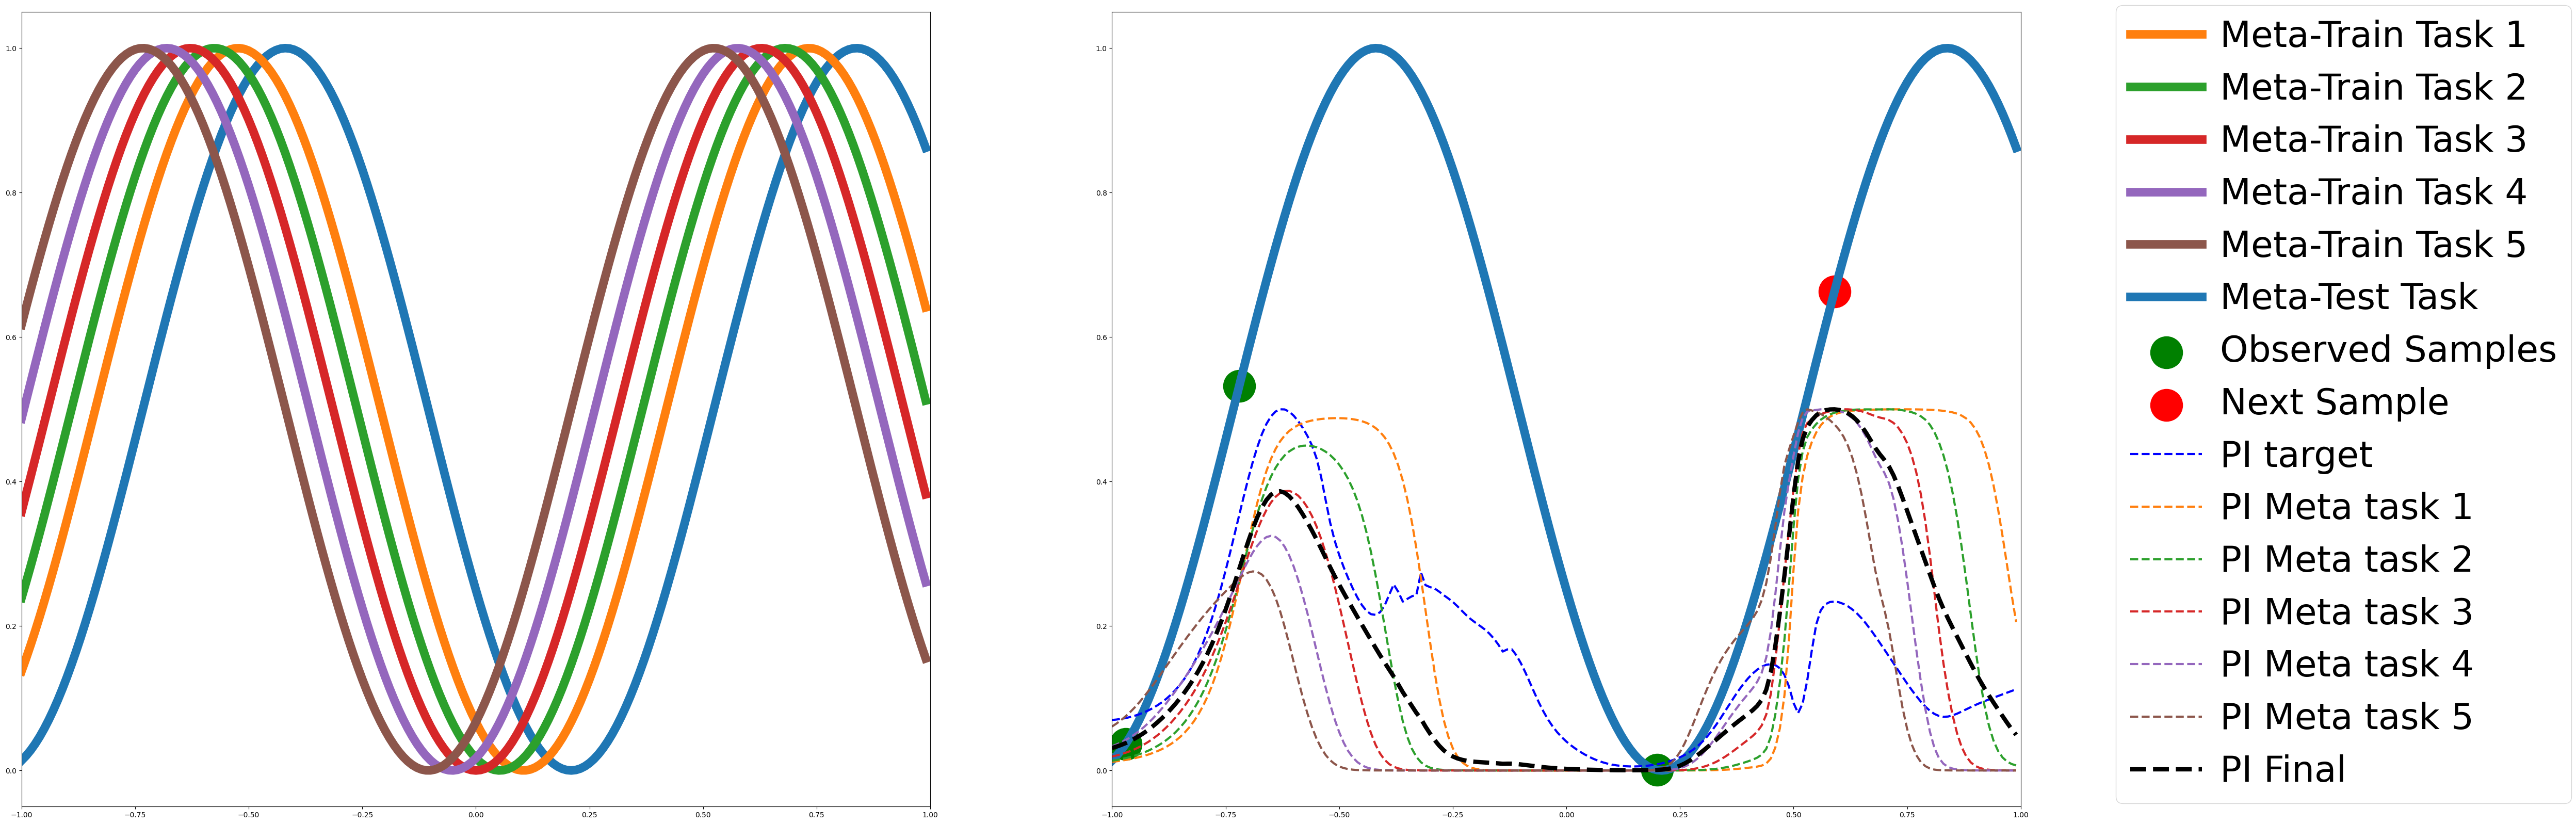

In [14]:
torch.manual_seed(0)
np.random.seed(0)
random.seed(31)
fontsize = 100
lw=12


X_spt, y_spt, X_qry, y_qry = get_batch_test(spt_size=3, task = 8 , step=0.01)

meta_data = {}
for i, task in enumerate(range(10,15)):
    if i == 0:
        y_shifted = f(X_qry, shift=task_shift(task))
    #elif i == 1:
    #    y_shifted = 0.5*f(X_qry, shift=task_shift(20))
    else:
        y_shifted = f(X_qry, shift=task_shift(task))
    meta_data[i] = {
            "X": X_qry,
            "y": y_shifted.squeeze(-1),
        }



fig, axs = plt.subplots(1,2, figsize=(50,20))



from our_pfns4bo import ourPFNs4BO_discrete
optimizer  = ourPFNs4BO_discrete(torch.load( pfns4bo.hebo_plus_model), meta_data)
for x,y in zip(X_spt,y_spt):
    optimizer.observe(x, y)


incumbent = X_spt[y_spt.argmax()].reshape(-1)

#print(incumbent,y_spt)
scores = optimizer.suggest(candidates=X_qry, return_actual_ei=True)[1]
idx_next = np.argmax(scores)
print(idx_next)
X_spt = torch.cat((X_spt, X_qry[idx_next].unsqueeze(-1)))
y_spt = torch.cat((y_spt, y_qry[idx_next].unsqueeze(-1)))

axs[1].plot(X_qry,y_qry, linewidth=lw, label="Meta-Test Task")
axs[1].scatter(X_spt[:-1], y_spt[:-1], s= 2000, c= "green", label="Observed Samples")
axs[1].scatter(X_spt[-1], y_spt[-1], s= 2000, c= "red", label="Next Sample")



pi = optimizer.pfnimputation.pi_target
pi =  0.5*pi/max(pi)
axs[ 1].plot(X_qry, pi, "--",linewidth=lw//4, label="PI target", c= "blue")
axs[1].set_xlim(-1,1)

for i, task in enumerate(range(10,15)):
    pi = optimizer.pfnimputation.pi_related[i]
    pi =  0.5*pi/max(pi)
    axs[ 1].plot(X_qry, pi, "--",linewidth=lw//4, label="PI Meta task "+str(i+1))
    axs[1].set_xlim(-1,1)

pi = 0.5*scores/max(scores)
axs[ 1].plot(X_qry, pi, "--",linewidth=lw//2, label="PI Final", c= "black")
axs[1].set_xlim(-1,1)


X_qry = torch.Tensor(np.arange(-1, 1, 0.01)).reshape(-1,1)
y_qry = f(X_qry, shift=task_shift(8))
axs[0].plot(X_qry, y_qry, linewidth=lw, label="\textbf{Meta-Test Task}")
#axs[0].scatter(X_spt[:-1], y_spt[:-1], s= 1000)

task_names = ["Meta-Train Task 1", "Meta-Train Task 2", "Meta-Train Task 3", "Meta-Train Task 4", "Meta-Train Task 5"]

for i, task in enumerate(range(10,15)):
    imputed_y = optimizer.pfnimputation.imputed_y
    axs[0].plot(meta_data[i]["X"], meta_data[i]["y"], linewidth=lw, label=task_names[i])
    #axs[0].scatter(X_spt[:-1], imputed_y[:, i], s= 1000)
    
axs[0].set_xlim(-1,1)


lines_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
lines.pop(0)
labels.pop(0)

anchor = (0.93, 0, 0.5, 1)
fig.legend(lines, labels,loc="center left", bbox_to_anchor=anchor, ncol=1, fontsize=fontsize*0.5,  handletextpad=0.5, labelspacing = 0.5, columnspacing=1.)
fig.subplots_adjust(wspace=0.2)

tensor([-0.1200]) tensor([[0.2103],
        [0.3123],
        [0.5382],
        [0.5160]]) tensor([[ 0.4000],
        [-0.8100],
        [-0.1200],
        [ 0.5300]])
Reliability scores: tensor([0.3319, 0.0713, 0.1836, 0.1531, 0.1358, 0.1243])
Reliability scores: tensor([0.3319, 0.0713, 0.1836, 0.1531, 0.1358, 0.1243])
158
tensor([0.8119, 0.5992, 0.4362, 0.4763]) tensor([ 0.2267,  0.0300, -0.1483, -0.1084])
tensor([0.4566, 0.6063, 0.1564, 0.8943]) tensor([-0.0731,  0.0886, -0.3766,  0.3610])
tensor([0.5817, 0.6905, 0.0730, 0.9651]) tensor([ 0.0027,  0.1245, -0.5093,  0.3821])
tensor([0.6980, 0.7544, 0.0148, 1.0076]) tensor([ 0.0761,  0.1483, -0.6081,  0.3837])
tensor([ 0.7956,  0.7976, -0.0088,  1.0172]) tensor([ 0.1433,  0.1566, -0.6628,  0.3628])


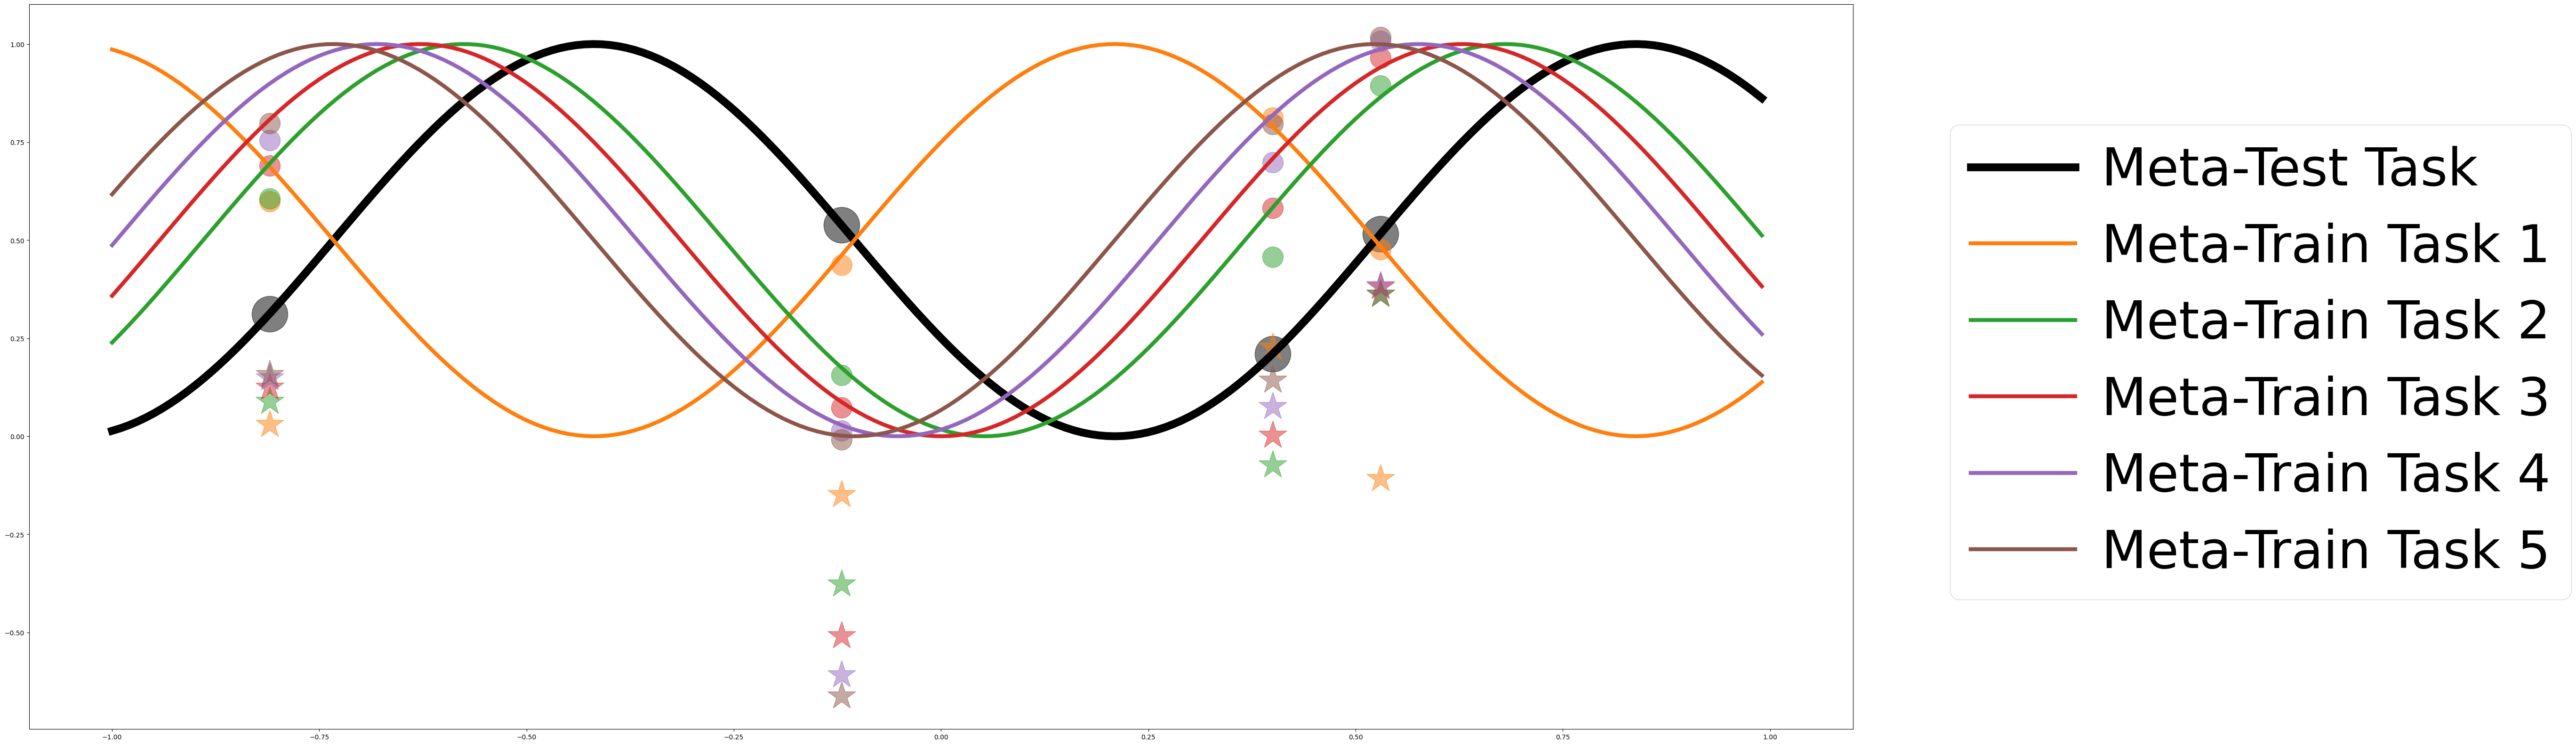

In [ ]:
torch.manual_seed(0)
np.random.seed(0)
random.seed(29)

X_spt, y_spt, X_qry, y_qry = get_batch_test(spt_size=4, task = 8 , step=0.01)

meta_data = {}
for i, task in enumerate(range(10,15)):
    if i == 0:
        y_shifted = f(X_qry, shift=task_shift(20))
    #elif i == 1:
    #    y_shifted = 0.5*f(X_qry, shift=task_shift(20))
    else:
        y_shifted = f(X_qry, shift=task_shift(task))
    meta_data[i] = {
            "X": X_qry,
            "y": y_shifted.squeeze(-1),
        }


from our_pfns4bo import ourPFNs4BO_discrete
optimizer  = ourPFNs4BO_discrete(torch.load( pfns4bo.hebo_plus_model), meta_data)
for x,y in zip(X_spt,y_spt):
    optimizer.observe(x, y)


incumbent = X_spt[y_spt.argmax()].reshape(-1)

print(incumbent,y_spt, X_spt)
scores = optimizer.suggest(candidates=X_qry, return_actual_ei=True)[1]
idx_next = np.argmax(scores)
print(idx_next)

# X_spt = torch.cat((X_spt, X_qry[idx_next].unsqueeze(-1)))
# y_spt = torch.cat((y_spt, y_qry[idx_next].unsqueeze(-1)))
fig, axs = plt.subplots(1, 1, figsize=(50, 20))

axs.plot(X_qry, y_qry, linewidth=lw, label="Meta-Test Task", c="black")
axs.scatter(X_spt, y_spt, s=3000, c="black", alpha=0.5)

for i, task in enumerate(range(10,15)):
    axs.plot(X_qry, meta_data[i]["y"], linewidth=lw//2, label="Meta-Train Task "+str(i+1), c="C{}".format(i+1))
    imputed_y = optimizer.pfnimputation.imputed_y
    axs.scatter(X_spt, imputed_y[:, i], s=1000, alpha=0.5, c="C{}".format(i+1))
    proj = optimizer.pfnimputation.y_proj
    print(imputed_y[:, i], proj[:, i])
    axs.scatter(X_spt, proj[:, i], s=2000, alpha=0.5, marker="*", c="C{}".format(i+1))

# X_qry = torch.Tensor(np.arange(-1, 1, 0.01)).reshape(-1,1)
# y_qry = f(X_qry, shift=task_shift(8))
# axs.plot(X_qry, y_qry, linewidth=lw, label="Meta-Test Task")

axs.set_xlim(-1.1, 1.1)
lines_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
# lines.pop(0)
# labels.pop(0)

anchor = (0.93, 0, 0.5, 1)
fig.legend(lines, labels, loc="center left", bbox_to_anchor=anchor, ncol=1, fontsize=fontsize*0.8, handletextpad=0.5, labelspacing=0.5, columnspacing=1.)
fig.subplots_adjust(wspace=0.2)